**CNN + GAN**

**GANs to Generate Color Images of Anime Faces**

In [4]:
anime_path = r"C:\Users\17934\Desktop\Artificial-Intelligence\3-Resources\Codes\DataSet\Figure\animeface"

In [5]:
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset
from PIL import Image
from pathlib import Path

transform = T.Compose([T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])
class AnimeFaceDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        self.image_paths = [
            path for path in Path(root).rglob("*")
            if path.is_file() and path.suffix.lower() in extensions
        ]

        if not self.image_paths:
            raise FileNotFoundError(f"未找到图片文件：{root}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, 0

train_data = AnimeFaceDataset(
    root=anime_path,
    transform=transform
)

print(f"找到 {len(train_data)} 张图片")


找到 63565 张图片


In [6]:
from torch.utils.data import DataLoader

batch_size = 128
train_loader = DataLoader(dataset=train_data, 
               batch_size=batch_size, shuffle=True)

In [7]:
image0, _ = train_data[0]


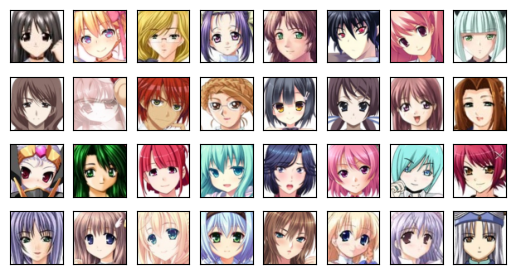

In [9]:
def plot_images(imgs):
    for i in range(32):
        ax = plt.subplot(4, 8, i + 1)
        plt.imshow(imgs[i].permute(1,2,0)/2+0.5)
        plt.xticks([])
        plt.yticks([])
    plt.subplots_adjust(hspace=-0.6)
    plt.show()  

imgs, _ = next(iter(train_loader))
plot_images(imgs)

In [10]:
import torch.nn as nn
import torch

# determine the device automatically
device = "cuda" if torch.cuda.is_available() else "cpu"
D = nn.Sequential(
    nn.Conv2d(3, 64, 4, 2, 1, bias=False),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Conv2d(64, 128, 4, 2, 1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Conv2d(128, 256, 4, 2, 1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Conv2d(256, 512, 4, 2, 1, bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),
    nn.Conv2d(512, 1, 4, 1, 0, bias=False),
    nn.Sigmoid(),
    nn.Flatten()).to(device)

In [11]:
G=nn.Sequential(
    nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),
    nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
    nn.Tanh()).to(device)

In [12]:
loss_fn=nn.BCELoss()
lr = 0.0002
optimG = torch.optim.Adam(G.parameters(), 
                         lr = lr, betas=(0.5, 0.999))
optimD = torch.optim.Adam(D.parameters(), 
                         lr = lr, betas=(0.5, 0.999))

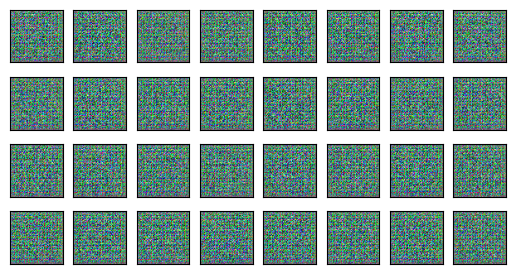

In [13]:
def test_epoch():
    noise = torch.randn(32,100,1,1).\
        to(device=device)    #A
    fake_samples=G(noise).cpu().detach()    #B
    for i in range(32):    #C
        ax = plt.subplot(4, 8, i + 1)
        img=(fake_samples.cpu().detach()[i]/2+0.5).\
            permute(1,2,0)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
    plt.subplots_adjust(hspace=-0.6)
    plt.show()
test_epoch()    #D     

In [14]:
real_labels=torch.ones((batch_size,1)).to(device)
fake_labels=torch.zeros((batch_size,1)).to(device)

In [15]:
def train_D_on_real(real_samples):
    real_samples=real_samples.to(device)
    preds=D(real_samples)
    labels=torch.ones((real_samples.shape[0],1)).to(device)
    loss_D=loss_fn(preds,labels)
    optimD.zero_grad()
    loss_D.backward()
    optimD.step()
    return loss_D  

In [16]:
def train_D_on_fake():
    noise=torch.randn(batch_size,100,1,1).to(device)
    generated_data=G(noise)
    preds=D(generated_data)
    loss_D=loss_fn(preds,fake_labels)
    optimD.zero_grad()
    loss_D.backward()
    optimD.step()
    return loss_D 

In [17]:
def train_G():
    noise=torch.randn(batch_size,100,1,1).to(device)
    generated_data=G(noise)
    preds=D(generated_data)
    loss_G=loss_fn(preds,real_labels)
    optimG.zero_grad()
    loss_G.backward()
    optimG.step()
    return loss_G   

epoch 1, dloss: 0.5819518566131592, gloss 6.508782386779785


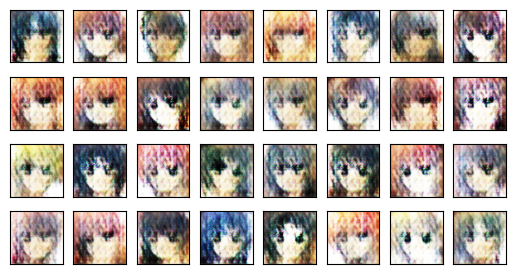

epoch 2, dloss: 0.4789261519908905, gloss 7.021466255187988


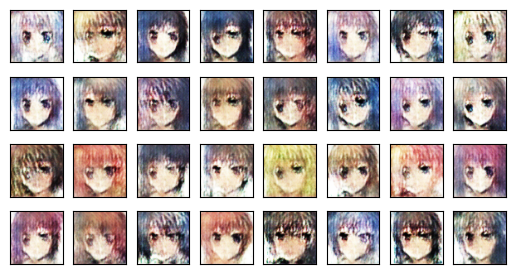

epoch 3, dloss: 0.3899668753147125, gloss 7.083640098571777


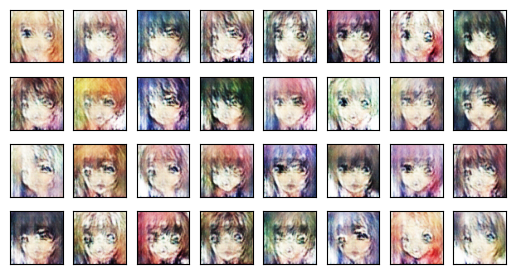

epoch 4, dloss: 0.3060797452926636, gloss 7.546606540679932


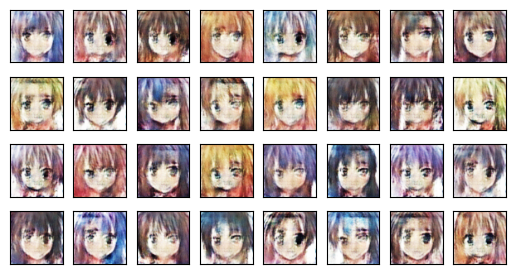

epoch 5, dloss: 0.28350764513015747, gloss 7.592060565948486


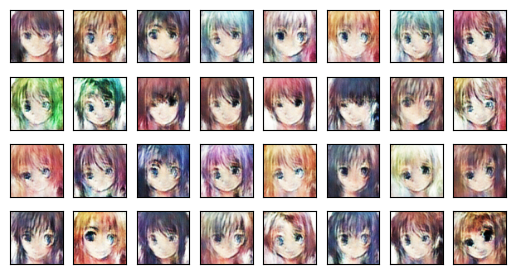

epoch 6, dloss: 0.24844379723072052, gloss 8.014512062072754


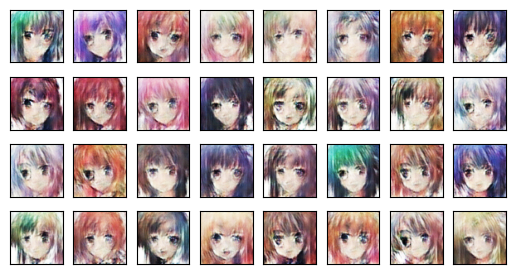

epoch 7, dloss: 0.22490327060222626, gloss 8.496650695800781


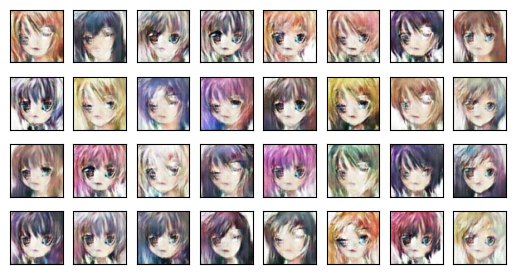

epoch 8, dloss: 0.18494802713394165, gloss 8.364173889160156


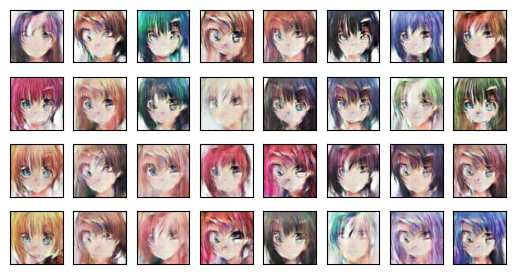

epoch 9, dloss: 0.17285683751106262, gloss 9.24895191192627


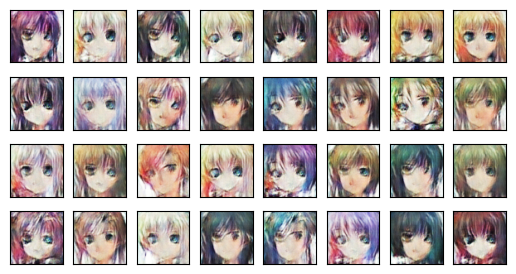

epoch 10, dloss: 0.17500635981559753, gloss 9.290383338928223


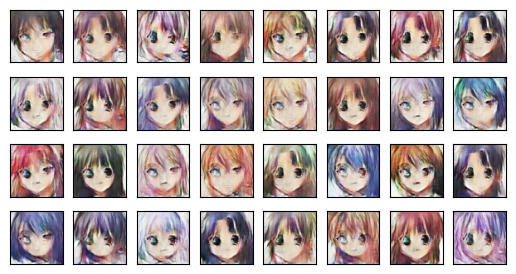

epoch 11, dloss: 0.23641365766525269, gloss 9.594523429870605


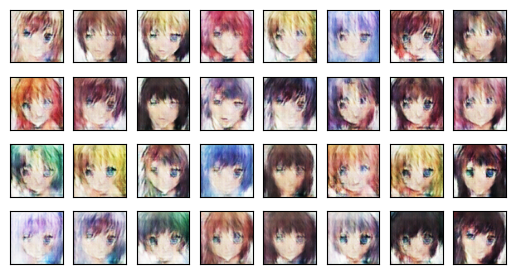

epoch 12, dloss: 0.12054256349802017, gloss 10.016255378723145


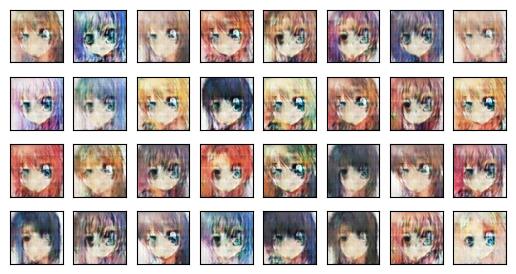

epoch 13, dloss: 0.16600674390792847, gloss 9.367788314819336


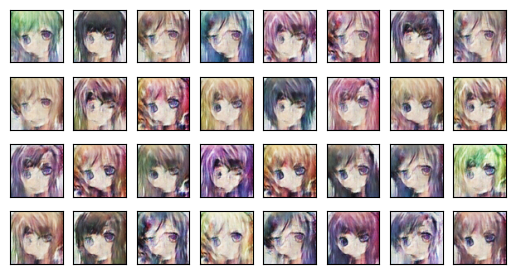

epoch 14, dloss: 0.1357274204492569, gloss 9.980563163757324


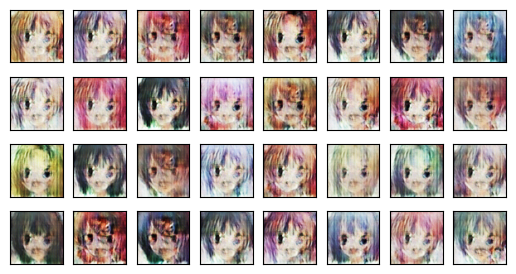

epoch 15, dloss: 0.15932638943195343, gloss 10.565374374389648


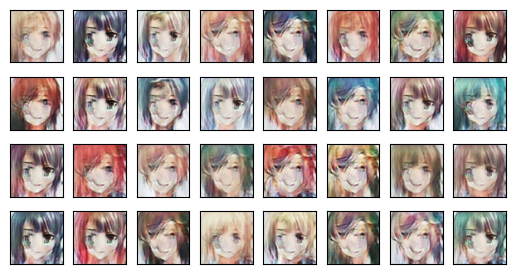

epoch 16, dloss: 0.13237452507019043, gloss 10.004470825195312


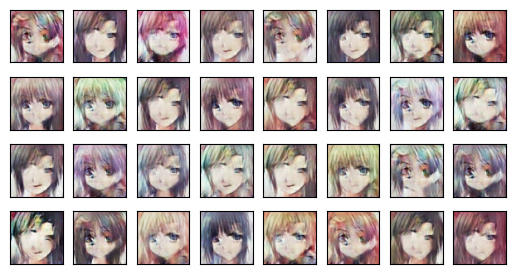

epoch 17, dloss: 0.17347341775894165, gloss 10.207469940185547


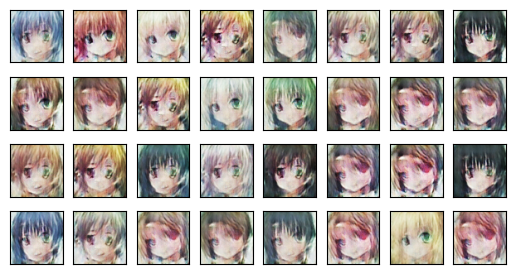

epoch 18, dloss: 0.10289640724658966, gloss 9.366246223449707


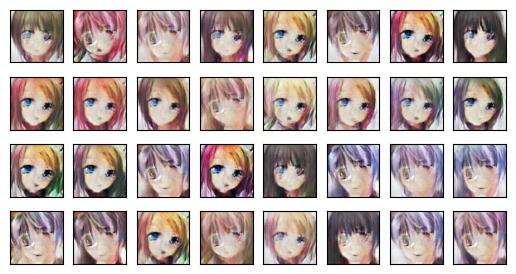

epoch 19, dloss: 0.18506745994091034, gloss 11.681633949279785


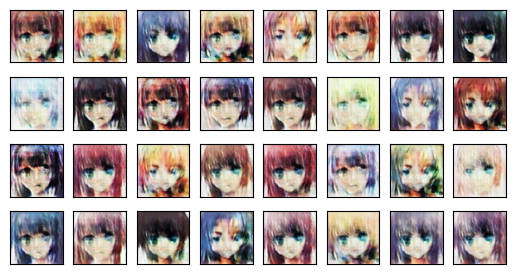

epoch 20, dloss: 0.09984012693166733, gloss 9.590226173400879


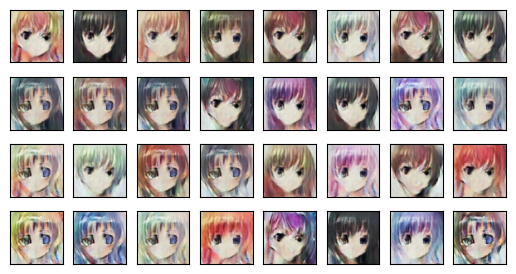

In [18]:
for i in range(20):
    gloss=0
    dloss=0
    for n, (real_samples,_) in enumerate(train_loader):    
        loss_D=train_D_on_real(real_samples)
        dloss+=loss_D
        loss_D=train_D_on_fake()
        dloss+=loss_D
        loss_G=train_G()
        gloss+=loss_G
    gloss=gloss/n
    dloss=dloss/n
    print(f"epoch {i+1}, dloss: {dloss}, gloss {gloss}")
    test_epoch()

In [19]:
# Export to TorchScript
scripted = torch.jit.script(G) 
scripted.save('files/anime_gen.pt') 

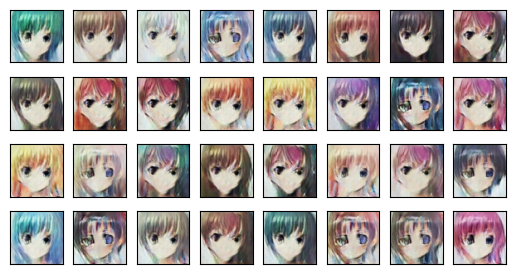

In [20]:
new_G=torch.jit.load('files/anime_gen.pt',
                     map_location=device)
new_G.eval()
noise=torch.randn(32,100,1,1).to(device)
fake_samples=new_G(noise).cpu().detach()
for i in range(32):
    ax = plt.subplot(4, 8, i + 1)
    img=(fake_samples.cpu().detach()[i]/2+0.5).permute(1,2,0)
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
plt.subplots_adjust(hspace=-0.6)
plt.show() 